In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/DATASET/diabetes.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
x=df.drop("Outcome",axis=1)
y=df["Outcome"]
accc_n =[]
for i in range(100):
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
  model=KNeighborsClassifier(n_neighbors=(i+1))
  model.fit(x_train,y_train)
  pre=model.predict(x_test)
  acc=accuracy_score(y_test,pre)
  accc_n.append({"acc":(acc*100),"n":(i+1)})

In [5]:
s = pd.DataFrame(accc_n)
s[s['acc']==s['acc'].max()]


,acc,n
11,77.922078,12
15,77.922078,16


In [6]:
x=df.drop("Outcome",axis=1)
y=df["Outcome"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc*100)
cf = confusion_matrix(y_test,pre)

67.53246753246754


In [7]:
#Confusion Matrix
print("Confusion Matrix:")
print(" T    F")
print('T',cf[0])
print("F",cf[1])
acc = (cf[0][0]+cf[1][1])/(cf.sum())
print("Accuracy:",acc*100)
print("Error Accuracy:",(1-acc)*100)
p = cf[0][0]/(cf[0][0]+cf[1][0])
print("Precision:",(p)*100)
r = cf[0][0]/(cf[0][0]+cf[0][1])
print("Recall:",(r)*100)
print("Specificity:",(cf[1][1]/(cf[1][1]+cf[1][0]))*100)
print("F1 Score:",(2*(p*r)/(p+r))*100)

Confusion Matrix:
 T    F
T [108  43]
F [32 48]
Accuracy: 67.53246753246754
Error Accuracy: 32.467532467532465
Precision: 77.14285714285715
Recall: 71.52317880794702
Specificity: 60.0
F1 Score: 74.22680412371135


In [8]:
class_report = classification_report(y_test,pre)
print(class_report)

              precision    recall  f1-score   support

           0       0.77      0.72      0.74       151
           1       0.53      0.60      0.56        80

    accuracy                           0.68       231
   macro avg       0.65      0.66      0.65       231
weighted avg       0.69      0.68      0.68       231



In [9]:
actual = [0,1,0,0,0,1,0,1,0,1]
predict = [1,1,0,0,1,1,0,1,1,0]
cf = confusion_matrix(actual,predict,labels=[0,1])
print(cf)
class_report = classification_report(actual,predict)
print(class_report)

[[3 3]
 [1 3]]
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.50      0.75      0.60         4

    accuracy                           0.60        10
   macro avg       0.62      0.62      0.60        10
weighted avg       0.65      0.60      0.60        10



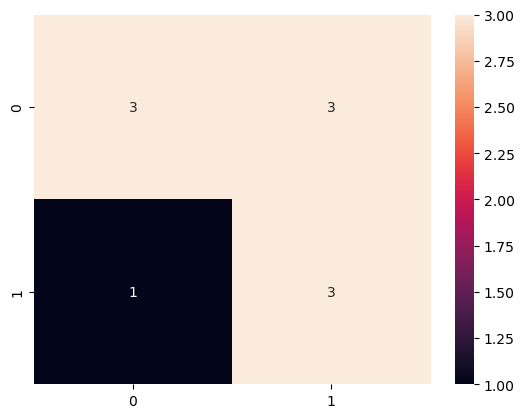

In [10]:
sns.heatmap(cf,annot=True)
plt.show()

In [11]:
df = pd.read_csv("/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/DATASET/Datasets/iris.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB
None


In [12]:
features = df.drop(columns=['Id','Species'],axis=1)
labels = df['Species']

x_train,x_test,y_train,y_test=train_test_split(features,labels,test_size=0.3,random_state=42)
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc*100)
print(confusion_matrix(y_test,pre))

100.0
[[17  0]
 [ 0 13]]
